In [1]:
version = "REPLACE_PACKAGE_VERSION"

# Assignment 2: Mining Itemsets (Part I)


Starting from this week, you will get your hands wet by playing with real-world data with your freshly learned data mining techniques.  To test your understanding of the concepts, you will be asked to implement some of these techniques by your own, for which you can only call from a restricted set of APIs.  In your own projects, of course, you are encouraged to use as many packages and APIs as you may. 

For this assignment, **we collected 10,000 orders from Instacart, a grocery ordering and delivery app**. You will represent this dataset as a collection of itemsets and practice what we learned in class -- mining and evaluating frequent itemsets, and calculating the similarity of itemsets. 

**Disclaimer**: The data are collected from the real world. As you step into the *wild*, things might not always be nice and clean. Although we, the instructing team, have tried our best effort to filter out data containing poisonous vocabularies and etc. It is still possible that you will encouter offensive contents. 

In this assignment, you will:

- Represent the dataset as a collection of itemsets and mine frequent patterns from it.
- Get familiar with a set of metrics for measuring the importance of patterns (support, frequency, lift, chi-square, mutual information).
- Calculate Jaccard similarity and find the top $k$ similar itemsets to a given itemset.
- Understand Apriori and implement a part of the algorithm.

Have fun and cheers!🍻

Now Part I begins. We will represent the dataset as a collection of itemsets and conduct some descriptive analysis. The purpose is to get you familiar with the data. You do not need to change any of the code blocks, but just execute all of them and examine the output. Please read through the text descriptions and the code blocks carefully. After you are done, feel free to further explore the dataset in your own ways. 

First, let's import the packages and dependencies that will be used later.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
from mads.lib.path import assets

## 1. Data Preprocessing

Let's start by loading the dataset and preview its first few lines. In this assignment, we will load two data files:
1. `orders.csv.zip`: This file contains the order information, whose columns are order ID and product ID.
2. `products.csv.zip`: This file contains the product information, which maps from product ID to its name.

In [3]:
file_orders = assets.find("orders.csv.zip")
file_products = assets.find("products.csv.zip")
orders = pd.read_csv(file_orders)
products = pd.read_csv(file_products)

In [4]:
orders = orders[["order_id", "product_id"]]
orders.head()

,order_id,product_id
0,2,33120
1,2,28985
2,2,9327
3,2,45918
4,2,30035


You should find each line of the data is a specific product but the product name is missing. And, obviously, an order may contain multiple products. Now, let's define a dictionary to map product ID to its name so that we can check what products do users buy.

In [5]:
products = products[["product_id", "product_name"]]
products.head()

,product_id,product_name
0,1,Chocolate Sandwich Cookies
1,2,All-Seasons Salt
2,3,Robust Golden Unsweetened Oolong Tea
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...
4,5,Green Chile Anytime Sauce


In [6]:
product_name_map = dict(zip(products["product_id"], products["product_name"]))

Now, we have all the information we need: the orders data and the products data. We can merge the products in the same order into a list.

In [7]:
# Group orders by order id and merge them into a list.
order_baskets = orders.groupby("order_id")["product_id"].apply(list)

# Convert the above pandas Series to a pandas DataFrame.
order_baskets = order_baskets.to_frame(name="products_id")

# Create a new column called size that denotes the order sizes.
order_baskets["size"] = order_baskets["products_id"].apply(len)

# Let's have a look at our processed data!
order_baskets.head()

,products_id,size
order_id,,
2,"[33120, 28985, 9327, 45918, 30035, 17794, 4014...",9
3,"[33754, 24838, 17704, 21903, 17668, 46667, 174...",8
4,"[46842, 26434, 39758, 27761, 10054, 21351, 225...",13
5,"[13176, 15005, 47329, 27966, 23909, 48370, 132...",26
6,"[40462, 15873, 41897]",3


We can use the `product_name_map` we created just now to figure out what products any given order contain. For example, order 42.

In [8]:
order_42 = order_baskets.loc[42]["products_id"]
for product_id in order_42:
    print(product_name_map[product_id])

Unsweetened Vanilla Almond Breeze
Pure Irish Butter
Bag of Organic Bananas


## 2. Summary Statistics

Before we jump into analyzing a dataset, it is always wise to take a look at some summary statistics first. 

Let's examine how many products are added in an order(`order_baskets.size`). We can plot its distribution.

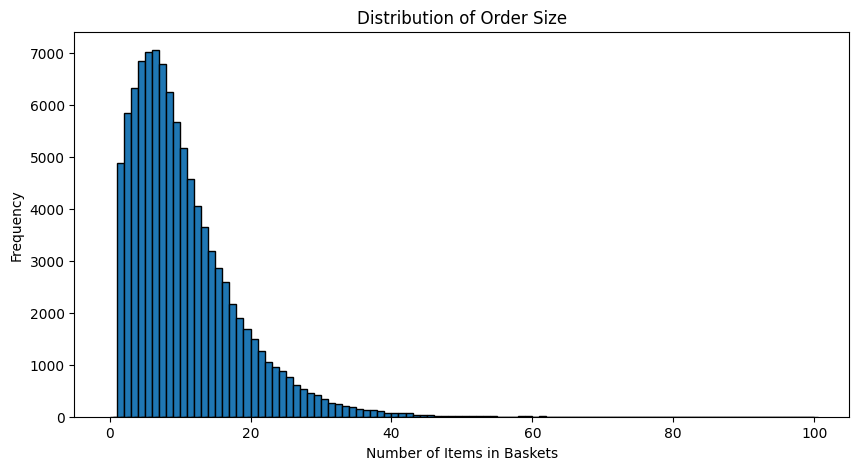

In [9]:
fig, ax = plt.subplots(figsize=(10,5))
ax.set_xlabel("Number of Items in Baskets")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Order Size")
ax.hist(order_baskets["size"], bins=200, range=(0,100), width=1, edgecolor="black")
plt.show()

The length of orders follow a log-normal distribution, which is consistent to [many other human behaviors](https://en.wikipedia.org/wiki/Log-normal_distribution#Occurrence_and_applications). For example, the length of comments posted in internet discussion forums, or even the length of chess games.

Next, we are now going to use the `mlxtend` for frequent itemset mining. This package requires that the itemsets be transformed into a matrix before being passed to its APIs, where each row represents an itemset and each column represents an item. Each cell encodes whether an item is in an itemset or not. You should know what this transformation does after doing the first assignment. Here we implement this transformation with the `MultiLabelBinarizer` in scikit-learn(`sklearn`).

In [10]:
mlb = MultiLabelBinarizer(sparse_output=True)
prod_matrix = pd.DataFrame.sparse.from_spmatrix(data=mlb.fit_transform(order_baskets["products_id"]), index=order_baskets.index, columns=mlb.classes_)
prod_matrix.head()

,1,2,3,4,8,9,10,12,14,15,...,49676,49677,49678,49679,49680,49681,49683,49685,49686,49688
order_id,,,,,,,,,,,,,,,,,,,,,
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
# Print the sparsity of the matrix
print("Sparsity: {:.2f}%".format(100 * prod_matrix.sparse.density))

Sparsity: 0.03%


*As you may expect, the matrix is very sparse. Only 0.03% of the cells are
non-zero. Previous versions of this assignment used a plain DataFrame to represent `prod_matrix` and allocated 26 GiB of memory. This version uses a pandas sparse array which results in `prod_matrix` only needing 36 MiB to represent the same information.*

Now, let's examine the popularity of individual products, that is, the counts and the distribution of single items (products). The number of orders containing a given product can be calculated as the sum of the column in the product matrix.

In [12]:
prod_popularity = prod_matrix.sum(axis=0)

for prod_id, prod_freq in prod_popularity.head().items():
    print(f"{product_name_map[prod_id]} - {prod_freq}")

Chocolate Sandwich Cookies - 59
All-Seasons Salt - 3
Robust Golden Unsweetened Oolong Tea - 3
Smart Ones Classic Favorites Mini Rigatoni With Vodka Cream Sauce - 10
Cut Russet Potatoes Steam N' Mash - 2


### Exercise 1. Find the most popular products (5 pts)
Please compete the `top_n_products` function below, which should return a list of the $n$ most popular products based on the `prod_popularity` DataFrame.

In [ ]:
def top_n_products(n):
    # sort product freq. in descending order and take the top n product IDs
    top_product_ids = prod_popularity.sort_values(ascending = False).head(n).index
    # convert product IDs to product names
    return [product_name_map[prod_id] for prod_id in top_product_ids]

In [ ]:
assert top_n_products(2) == [
    'Banana',
    'Bag of Organic Bananas'
]
assert top_n_products(5) == [
    'Banana',
    'Bag of Organic Bananas',
    'Organic Strawberries',
    'Organic Baby Spinach',
    'Organic Hass Avocado'
]


Why this works:

- `prod_popularity` stores the count of orders containing each product.
- Sorting it descending gives the most popular product IDs first.
- `product_name_map` converts those IDs into readable product names.

Expected outputs from the provided tests:

- `top_n_products(2) → ['Banana', 'Bag of Organic Bananas']`
- `top_n_products(5) → ['Banana', 'Bag of Organic Bananas', 'Organic Strawberries', 'Organic Baby Spinach', 'Organic Hass Avocado']`

The most popular products turn out to be banana and organic bananas! Is it a surprise? 🍌